# Development example for GRS step-by-step application to Landsat images

In [16]:
'''
Main program
'''

import os
import glob

import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import xarray as xr
import pandas as pd

import logging

import panel as pn

import cartopy.crs as ccrs
import geopandas as gpd

import GRSdriver
import grs
from grs import Product, AuxData, acutils, CamsProduct, L2aProduct, Rasterization
import grstbx
from grstbx import visual

pn.extension()
opj = os.path.join

print(f'-GRSdriver: {GRSdriver.__version__}')
print(f'-grs: {grs.__version__}')
print(f'-grstbx: {grstbx.__version__}')



-GRSdriver: 1.0.4
-grs: 2.1.6
-grstbx: 2.0.2


### Indicate the path where you put the look-up table file

In [2]:
lut_file = '/data/vrtc/xlut/toa_lut_opac_wind_light.nc'
lut_file = '/data/vrtc/xlut/toa_lut_opac_wind_light_v2.nc'
trans_lut_file = '/data/vrtc/xlut/transmittance_lut_opac_wind_light_v2.nc'

### Set the path of your Sentinel-2 image and corresponding CAMS file

In [3]:
file ='/data/satellite/landsat/LC09_L1TP_196030_20221120_20230321_02_T1'

file_nc = file+'.nc'

cams_file = '/data/cams/world/cams_forecast_2022-11.nc'

In [4]:
l1c = GRSdriver.LandsatDriver(file)
l1c.INFO

bandId,0,1,2,3,4,5,6,7,8
ESA,B01,B02,B03,B08,B04,B05,B09,B06,B07
EOREADER,CA,BLUE,GREEN,PAN,RED,NIR,SWIR_CIRRUS,SWIR_1,SWIR_2
Wavelength (nm),443,490,560,590,665,865,1370,1610,2190
Band width (nm),25,60,60,173,33,28,21,95,287
Resolution (m),30,30,30,15,30,30,30,30,30


In [5]:
l1c.load_mask()

In [6]:
l1c.load_product()

/home/harmel/anaconda3/envs/grstbx/lib/python3.9/site-packages/xarray/core/indexes.py:659: RuntimeWarning: '<' not supported between instances of 'SpectralBandNames' and 'SpectralBandNames', sort order is undefined for incomparable objects.
  new_pd_index = pd_indexes[0].append(pd_indexes[1:])


In [7]:
prod = Product(l1c.prod)
prod.raster

<xarray.Dataset>
Dimensions:      (x: 7671, y: 7791, wl: 9, wl_hr: 2951)
Coordinates:
  * x            (x) float64 5.349e+05 5.349e+05 5.35e+05 ... 7.65e+05 7.65e+05
  * y            (y) float64 4.899e+06 4.899e+06 ... 4.666e+06 4.666e+06
    spatial_ref  int64 0
  * wl           (wl) int64 443 490 560 590 665 865 1370 1610 2190
  * wl_hr        (wl_hr) float64 400.0 401.0 402.0 ... 1.35e+04 1.35e+04
    time         datetime64[ns] 2022-11-20T10:24:21
    band         int64 1
Data variables:
    bands        (wl, y, x) float32 nan nan nan nan nan ... nan nan nan nan nan
    SRF          (wl, wl_hr) float64 ...
    wl_true      (wl) float64 442.8 482.3 560.9 ... 1.608e+03 2.201e+03
    sza          (y, x) float32 nan nan nan nan nan nan ... nan nan nan nan nan
    vza          (y, x) float32 nan nan nan nan nan nan ... nan nan nan nan nan
    raa          (y, x) float32 nan nan nan nan nan nan ... nan nan nan nan nan
    l1c_flag     (y, x) uint32 1 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1 1
    surfwater    (y, x) int8 1 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1 1 1
Attributes: (12/20)
    long_name:              CA BLUE GREEN PAN RED NIR SWIR_CIRRUS SWIR_1 SWIR_2
    constellation:          Landsat-9
    constellation_id:       L9
    product_path:           /data/satellite/landsat/LC09_L1TP_196030_20221120...
    product_name:           LC09_L1TP_196030_20221120_20230321_02_T1
    product_filename:       LC09_L1TP_196030_20221120_20230321_02_T1
    ...                     ...
    satellite:              Landsat-9
    solar_irradiance:       NA
    solar_irradiance_unit:  W/m²/µm
    processing_time:        2024-04-19T09:42:16.577630
    processor:              grs_2.1.6
    version:                2.1.6

### Load the image and convert it into netcdf for further fatest loading (not necessary)

In [8]:

#l1c.prod.to_netcdf(file_nc)
#prod = Product(xr.open_dataset(file_nc))

### Visualize, interact and subset your region of interest
Yuo can use the "polygon" tool to subset the image and proceed with further processing

In [9]:
v=visual.view_spectral(prod.raster.bands,reproject=True)

In [10]:
v.title="## Landsat-9 L1C"
v.minmaxvalues=(0,0.3)
v.minmax=[0,0.5]
v.visu()

Column
    [0] WidgetBox
        [0] Markdown(str)
        [1] Column
            [0] Row
                [0] Markdown(str)
                [1] RadioButtonGroup(options=[0, 1, 2, 3, 4, ...], value=2)
            [1] Row
                [0] Row
                    [0] Markdown(str)
                    [1] DatePicker(enabled_dates=[datetime.date(2022, ...], start=datetime.date(2022, ..., value=datetime.date(2022, ...)
                [1] Row
                    [0] Markdown(str)
                    [1] Select(options=['CartoDark', ...], value='CartoDark')
            [2] Row
                [0] Row
                    [0] Markdown(str)
                    [1] EditableRangeSlider(end=0.5, name='Range Slider', step=0.0001, value=(0, 0.3), width=300)
                [1] Row
                    [0] Markdown(str)
                    [1] FloatSlider(name='Opacity', step=0.05, value=0.95)
                [2] Row
                    [0] Markdown(str)
                    [1] Select(options=['CET_D13', 'bky', ...], value='CET_D13')
        [2] HoloViews(DynamicMap, height=800, sizing_mode='fixed', width=1200)

You can save the area of interest into a json file for reuse (uncomment the next two cells)

In [20]:
#geom_ = v.get_geom(v.aoi_stream,crs=prod.raster.rio.crs)

In [21]:
#geom_.to_file("roi_example.json", driver="GeoJSON")

In [22]:
geom_ = gpd.read_file("roi_example.json", driver="GeoJSON")

In [23]:
raster_clipped = xr.Dataset()
prod.raster.bands.rio.clip(geom_.geometry.values)
for param in prod.raster.keys():
    da = prod.raster[param]
    if 'x' in da.dims and 'y' in da.dims:
        raster_clipped[param]=da.rio.clip(geom_.geometry.values)
    else:
        raster_clipped[param]=da
raster_clipped.attrs = prod.raster.attrs

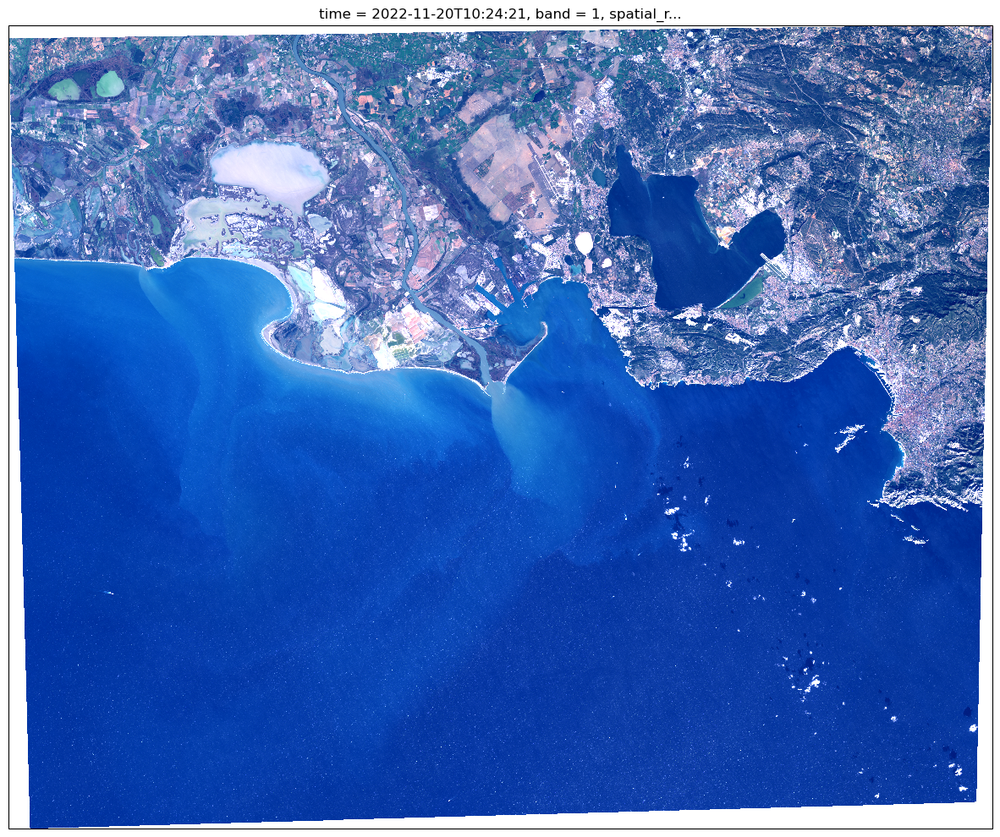

In [24]:

str_epsg = str(raster_clipped.rio.crs)
zone = str_epsg[-2:]
is_south = str_epsg[2] == 7
proj = ccrs.UTM(zone, is_south)

plt.figure(figsize=(15,15))
raster_clipped.bands.sel(wl=[665,560,490]).plot.imshow(rgb='wl', robust=True,subplot_kws=dict(projection=proj))

## Start GRS processing

If you want to process the whole tile comment the following line

In [12]:
prod.raster = raster_clipped

Set sensor specific parameters

In [13]:
if 'S2' in prod.sensor:
    monoview = False
else:
    monoview = True    
_R_ = Rasterization(monoview=monoview)

Start by checking the CAMS data

In [14]:
##################################
# GET ANCILLARY DATA (Pressure, O3, water vapor, NO2...
##################################

cams = CamsProduct(prod.raster, cams_file=cams_file)
#cams.wls=[355,380,400,440,469,500, 550, 645,670,800, 865,1020, 1240,1640,2130]
cams.load()

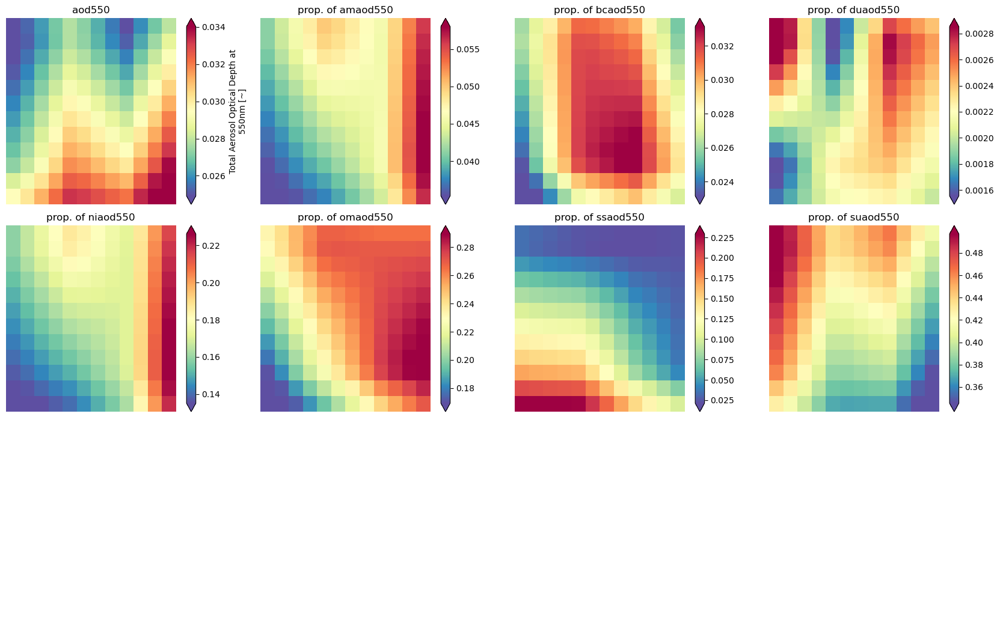

In [15]:
params=['aod550','amaod550', 'bcaod550', 'duaod550', 'niaod550', 'omaod550', 'ssaod550', 'suaod550']
Nrows = (len(params) + 4) // 4
fig, axs = plt.subplots(Nrows, 4, figsize=(4 * 4.2, Nrows * 3.5))
axs = axs.ravel()
[axi.set_axis_off() for axi in axs]
aod550 = cams.raster['aod550']
aod550
for i, param in enumerate(params):
    if i == 0:
        fig = cams.raster[param].plot.imshow(robust=True, ax=axs[i],cmap=plt.cm.Spectral_r)
        fig.axes.set_title(param)
    else:
        fig = (cams.raster[param]/aod550).plot.imshow(robust=True, ax=axs[i],cmap=plt.cm.Spectral_r)
        fig.axes.set_title('prop. of '+param)
    #fig.colorbar.set_label(self.raster[param].units)
    fig.axes.set(xticks=[], yticks=[])
    fig.axes.set_ylabel('')
    fig.axes.set_xlabel('')
plt.tight_layout()

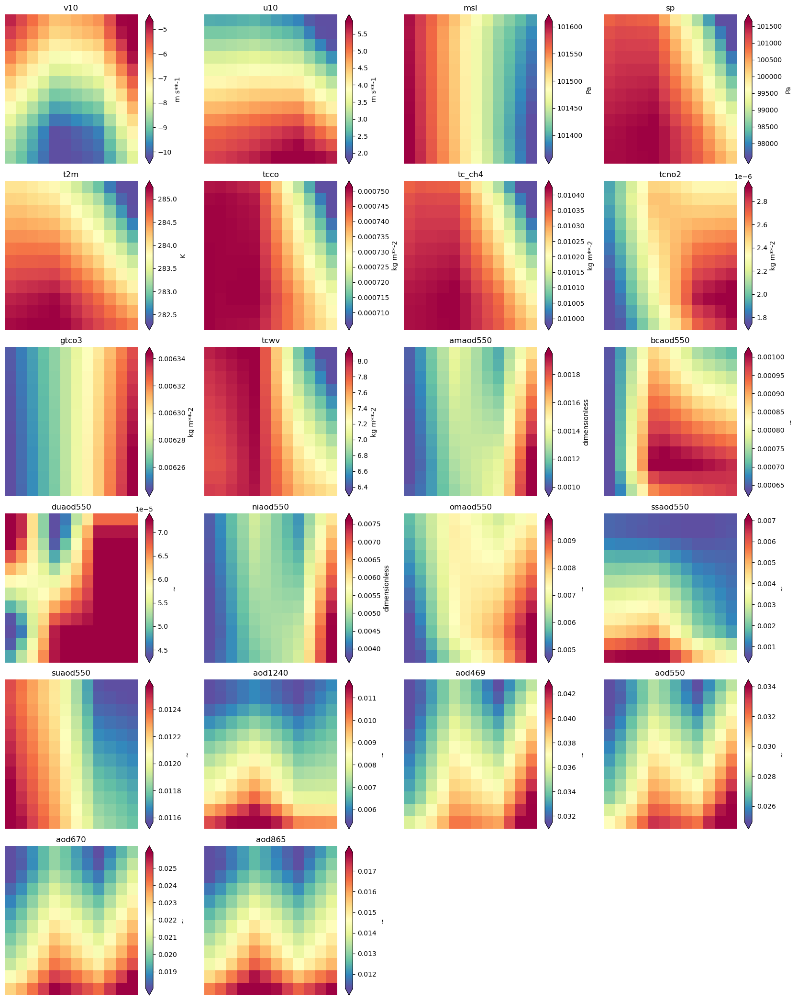

In [16]:
#cams.plot_params(params=['aod550', 'aod2130', 'ssa550', 't2m', 'msl', 'sp','tcco', 'tchcho', 'tc_oh', 'tc_ch4', 'tcno2', 'gtco3', 'tc_c3h8', 'tcwv', 'u10', 'v10'], cmap=plt.cm.Spectral_r)
#'ammonium_aerosol_optical_depth_550nm', 'black_carbon_aerosol_optical_depth_550nm',
#                'dust_aerosol_optical_depth_550nm',
#                'nitrate_aerosol_optical_depth_550nm', 'organic_matter_aerosol_optical_depth_550nm',
#                'sea_salt_aerosol_optical_depth_550nm',
#                'sulphate_aerosol_optical_depth_550nm',
cams.plot_params(params=['v10','u10', 'msl', 'sp','t2m', 'tcco', 'tc_ch4', 'tcno2', 'gtco3', 'tcwv',
 'amaod550', 'bcaod550', 'duaod550', 'niaod550', 'omaod550', 'ssaod550', 'suaod550',
 'aod1240', 'aod469', 'aod550', 'aod670', 'aod865',
 
 ],


                 cmap=plt.cm.Spectral_r)
plt.show()

In [17]:
cams.raster

<xarray.Dataset>
Dimensions:      (y: 12, x: 12)
Coordinates:
    time         datetime64[ns] 2022-11-20T10:24:21
    band         int64 1
  * x            (x) float64 6.109e+05 6.193e+05 ... 6.949e+05 7.032e+05
  * y            (y) float64 4.836e+06 4.83e+06 ... 4.779e+06 4.773e+06
    spatial_ref  int64 0
Data variables: (12/22)
    v10          (y, x) float64 -5.025 -5.394 -5.787 ... -9.318 -8.67 -8.023
    t2m          (y, x) float64 284.0 284.0 284.0 283.9 ... 284.8 284.7 284.6
    msl          (y, x) float64 1.016e+05 1.016e+05 ... 1.014e+05 1.014e+05
    sp           (y, x) float64 1.009e+05 1.01e+05 ... 1.004e+05 1.002e+05
    amaod550     (y, x) float64 0.001014 0.001101 0.001196 ... 0.001824 0.002035
    bcaod550     (y, x) float64 0.0006425 0.0006895 ... 0.0009669 0.000973
    ...           ...
    tcco         (y, x) float64 0.0007496 0.0007498 ... 0.0007337 0.000731
    tc_ch4       (y, x) float64 0.01035 0.01035 0.01035 ... 0.01029 0.01026
    tcno2        (y, x) float64 1.928e-06 2.046e-06 ... 2.822e-06 2.874e-06
    gtco3        (y, x) float64 0.006246 0.006252 0.006258 ... 0.006333 0.006347
    tcwv         (y, x) float64 7.999 8.032 8.061 8.091 ... 7.47 7.416 7.363
    u10          (y, x) float64 2.538 2.525 2.549 2.573 ... 5.934 5.813 5.693
Attributes:
    Conventions:  CF-1.6
    history:      2024-02-21 18:34:02 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

You may also want to visualize the module wind speed or the mean square slope (sigma2 taken from the Cox Munk isotropic model)

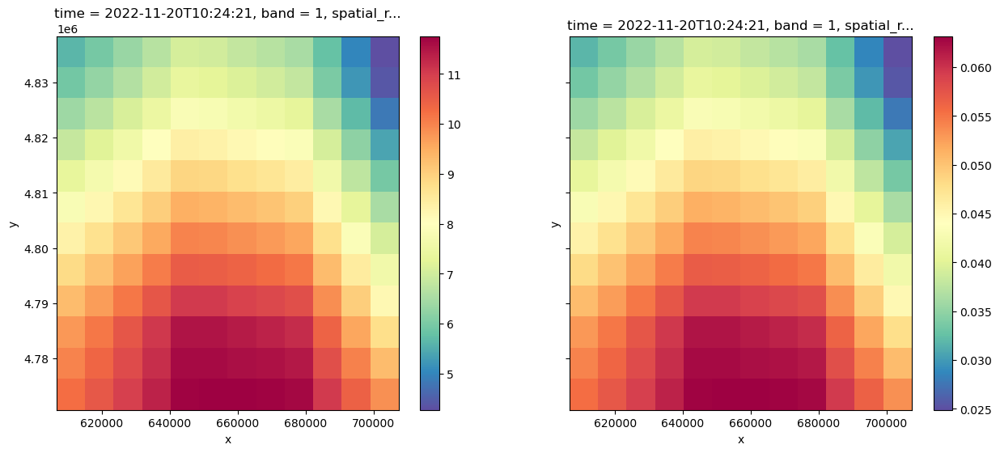

In [18]:

wind = np.sqrt(cams.raster['v10']**2+cams.raster['u10']**2)
sigma2=(wind+0.586)/195.3

fig,axs = plt.subplots(1,2,figsize=(15,6),sharey=True,sharex=True)
wind.plot.imshow(ax=axs[0],cmap=plt.cm.Spectral_r)
sigma2.plot.imshow(ax=axs[1],cmap=plt.cm.Spectral_r)

You can also plot a cams parameter as a new layer above the S2 RGB image

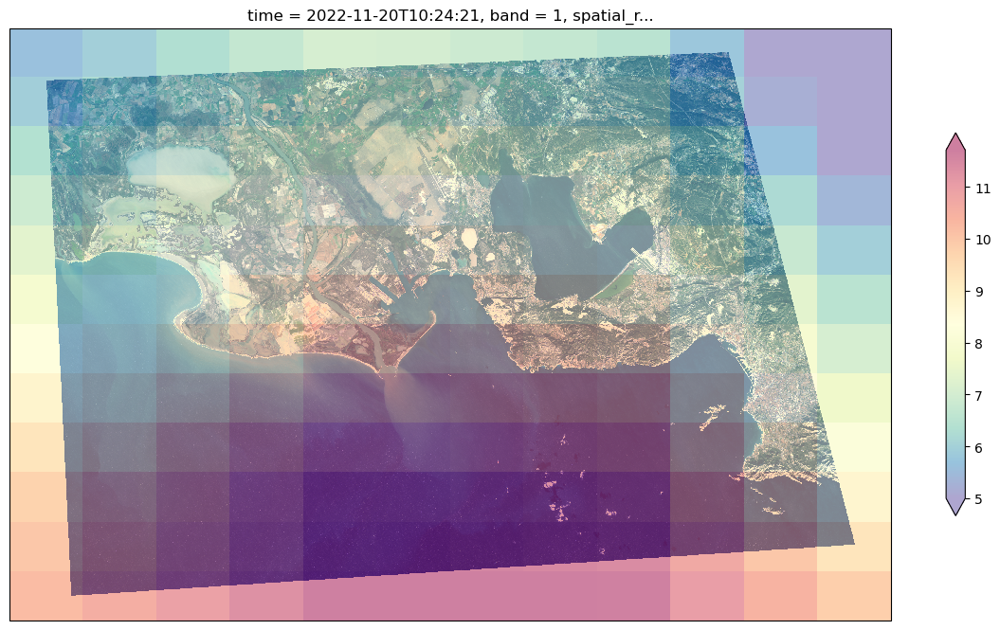

In [19]:
plt.figure(figsize=(15,15))

prod.raster.bands.sel(wl=[665,560,490]).plot.imshow(rgb='wl', robust=True,subplot_kws=dict(projection=proj))
wind.plot.imshow( cmap=plt.cm.Spectral_r,robust=True,alpha=0.5,subplot_kws=dict(projection=proj),cbar_kwargs={'shrink':0.35})

Take the mean values for LUT selection and interpolation 

In [20]:
_sigma2 = sigma2.mean().values
_wind = wind.mean().values
print(_sigma2,_wind)

0.047643660610375345 8.718806917206305


Prepare spectral bands for further processing and load LUT
Set parameter 'wl_to_process'

In [21]:
#####################################
# SUBSET RASTER TO KEEP REQUESTED BANDS
#####################################
if prod.bcirrus:
    prod.cirrus = prod.raster.bands.sel(wl=prod.bcirrus, method='nearest')
if prod.bwv:
    prod.wv = prod.raster.bands.sel(wl=prod.bwv, method='nearest')
prod.raster = prod.raster.sel(wl=prod.wl_process, method='nearest')


In [22]:
#####################################
# LOAD LUT FOR ATMOSPHERIC CORRECTION
#####################################
#logging.info('loading lut...' + prod.lutfine)

Ttot_Ed = xr.open_dataset(trans_lut_file)
Ttot_Ed['wl'] = Ttot_Ed['wl'] * 1000

aero_lut = xr.open_dataset(lut_file)
aero_lut['wl']=aero_lut['wl']*1000
aero_lut['aot'] = aero_lut.aot.isel(wind=0).squeeze()
# remove URBAN aerosol model for this example.drop_sel(model='URBA_rh70')
models=aero_lut.drop_sel(model='URBA_rh70').model.values
#aero_lut
wl_true = prod.raster.wl_true
_auxdata = AuxData(wl=wl_true)#wl=masked.wl)
sunglint_eps = _auxdata.sunglint_eps#['mean'].interp(wl=wl_true)
rot = _auxdata.rot#.interp(wl=wl_true)

## Set aerosol model from CAMS data

Get spectral aerosol optical thickness from CAMS raster

In [23]:
cams_aot_mean = cams.cams_aod.mean(['x','y'])
cams_aot_ref = cams.cams_aod.interp(wl=550,method='quadratic').compute()
cams_aot_ref_mean =  cams_aot_ref.mean(['x','y'])


Check proximity with tabulated models (LUT) and select representative aerosol model

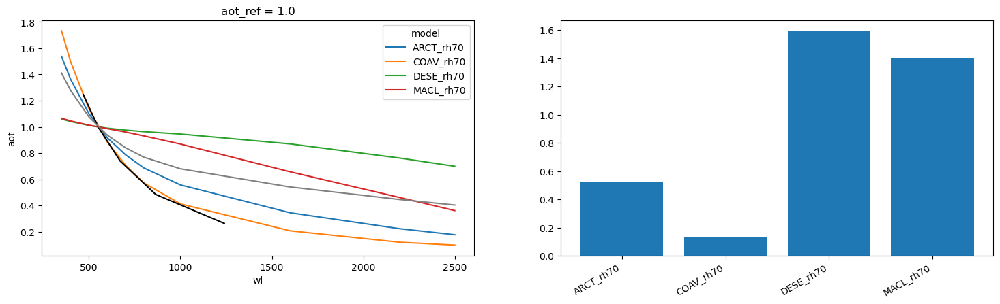

COAV_rh70


In [24]:


fig, axs = plt.subplots(1, 2, figsize=(18, 4.5))
aero_lut.aot.sel(model=models,aot_ref=1).plot(ax=axs[0],hue='model')#,add_legend=False)
(cams_aot_mean/cams_aot_ref_mean).plot(ax=axs[0],color='black')
aero_lut.aot.isel(model=[4,2]).mean('model').sel(aot_ref=1).plot(ax=axs[0],color='grey')
lut_aod=aero_lut.aot.sel(model=models,aot_ref=1).interp(wl=cams.cams_aod.wl)
rank = np.abs((cams_aot_mean/cams_aot_ref_mean)-lut_aod).sum('wl') 
axs[1].bar(x=rank.model, height=rank.values)
plt.xticks(rotation=30, ha='right')
plt.show()

idx = np.abs((cams_aot_mean/cams_aot_ref_mean)-lut_aod).sum('wl').argmin()
opac_model = aero_lut.sel(model=models).model.values[idx]
print(opac_model)

#    absorbing gases correction


In [25]:

gas_trans = acutils.GaseousTransmittance(prod, cams)
Tg_raster = gas_trans.get_gaseous_transmittance()
#Tg_raster

In [26]:
logging.info('correct for gaseous absorption')
for wl in prod.raster.wl.values:
    Tg_ = Tg_raster.sel(wl=wl).interp(x=prod.raster.x, y=prod.raster.y)
    prod.raster['bands'].loc[wl] = prod.raster.bands.sel(wl=wl) / Tg_
    del Tg_
prod.raster.bands.attrs['gas_absorption_correction'] = True

INFO:root:correct for gaseous absorption


In [27]:
import gc
gc.collect()

158121

You can check the gaseous transmittance for each spectral band

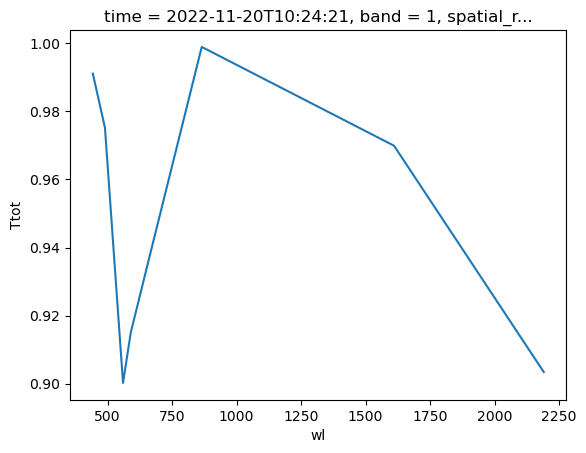

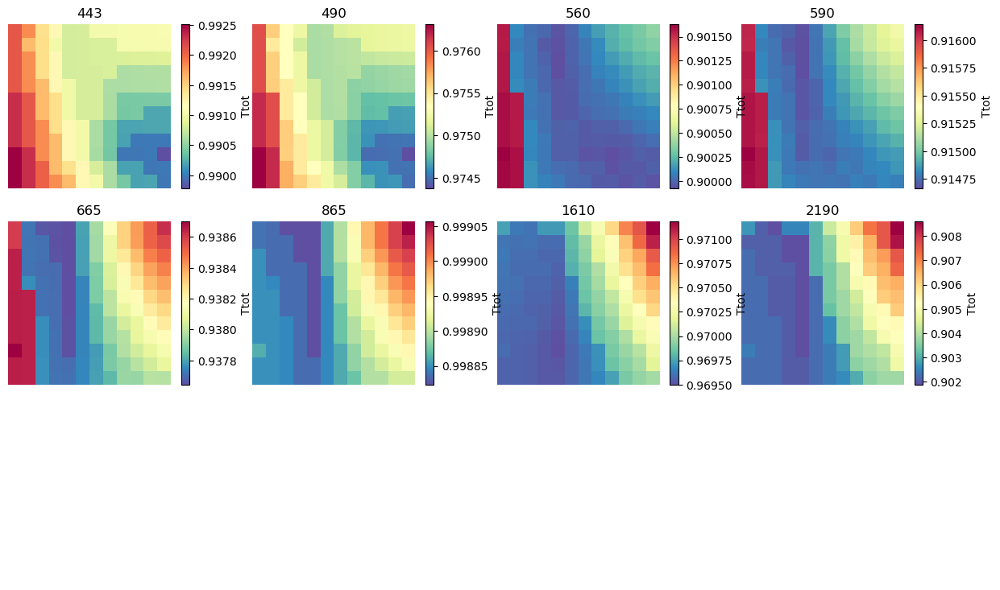

In [28]:
plt.figure()
Tg_raster.mean('x').mean('y').plot()
fig,axs = plt.subplots(3,4,figsize=(15,9),sharey=True,sharex=True)
axs=axs.ravel()
[axi.set_axis_off() for axi in axs]
for iwl in range(len(prod.wl_process)):
    #axs[iwl].set_axis_on()
    Tg_raster.isel(wl=iwl).plot(ax=axs[iwl],cmap=plt.cm.Spectral_r)
    axs[iwl].set_title( str(Tg_raster.isel(wl=iwl).wl.values))


# Water mask


In [29]:
# Compute NDWI

#green = prod.raster.bands.sel(wl=565,method='nearest')
#nir = prod.raster.bands.sel(wl=prod.b865)

green = prod.raster.bands.sel(wl=prod.bvis,method='nearest')
nir = prod.raster.bands.sel(wl=prod.bnir,method='nearest')#prod.b865)
swir = prod.raster.bands.sel(wl=prod.bswir)
b2200 = prod.raster.bands.sel(wl=prod.bswir2)

ndwi = (green - nir) / (green + nir)
ndwi_swir = (green - swir) / (green + swir)

prod.raster['ndwi'] = ndwi
prod.raster.ndwi.attrs = {
'description': 'Normalized difference spectral index between bands at ' + str(prod.bvis) + ' and ' + str(
    prod.bnir) + ' nm', 'units': '-'}
prod.raster['ndwi_swir'] = ndwi_swir
prod.raster.ndwi_swir.attrs = {
'description': 'Normalized difference spectral index between bands at ' + str(prod.bvis) + ' and ' + str(
    prod.bswir) + ' nm', 'units': '-'}

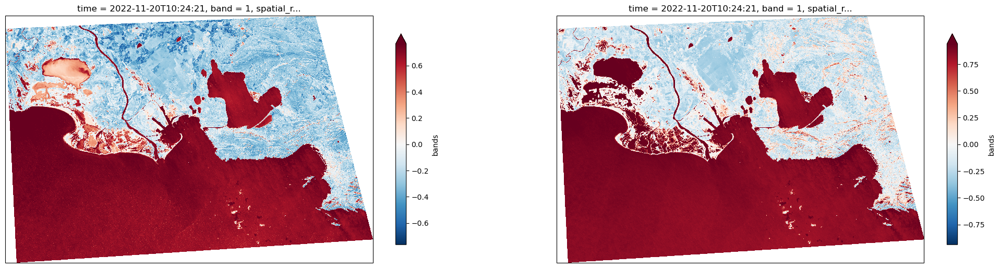

In [30]:
fig = plt.figure(figsize=(25, 15))
ax = plt.subplot(1, 2, 1, projection=proj)
ndwi.plot.imshow(robust=True,subplot_kws=dict(projection=proj),cbar_kwargs={'shrink':0.35})#,vmin=-0.1,vmax=0.1,cmap=plt.cm.RdBu_r) 
ax = plt.subplot(1, 2, 2, projection=proj)
ndwi_swir.plot.imshow(robust=True,subplot_kws=dict(projection=proj),cbar_kwargs={'shrink':0.35})#,vmin=-0.1,vmax=0.1,cmap=plt.cm.RdBu_r) 

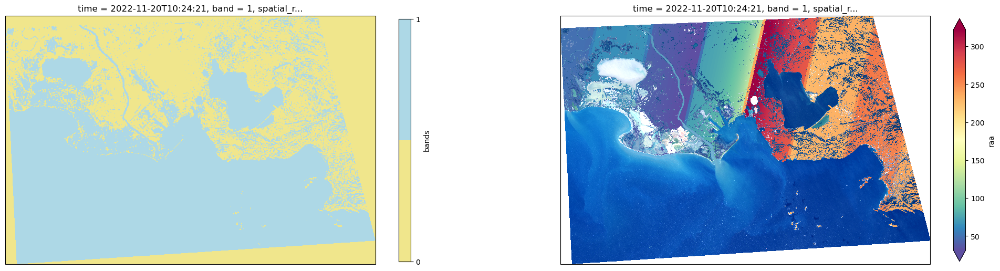

In [31]:
mask =  (ndwi_swir > 0) &  (b2200 < 0.2)#(ndwi > -0.0) &
masked = prod.raster.bands.where(mask)

from matplotlib.colors import ListedColormap
# binary cmap
bcmap = ListedColormap(['khaki', 'lightblue'])
xmask = xr.where(mask,1,0)

fig = plt.figure(figsize=(25, 15))
ax = plt.subplot(1, 2, 1, projection=proj)
xmask.plot.imshow(ax=ax,cmap=bcmap, cbar_kwargs={'ticks': [0, 1], 'shrink': 0.4})
ax = plt.subplot(1, 2, 2, projection=proj)
prod.raster['raa'].plot.imshow(cmap=plt.cm.Spectral_r, ax=ax, robust=True,cbar_kwargs={'shrink':0.4})
masked.sel(wl=[665,560,490]).plot.imshow(rgb='wl', robust=True,ax=ax)


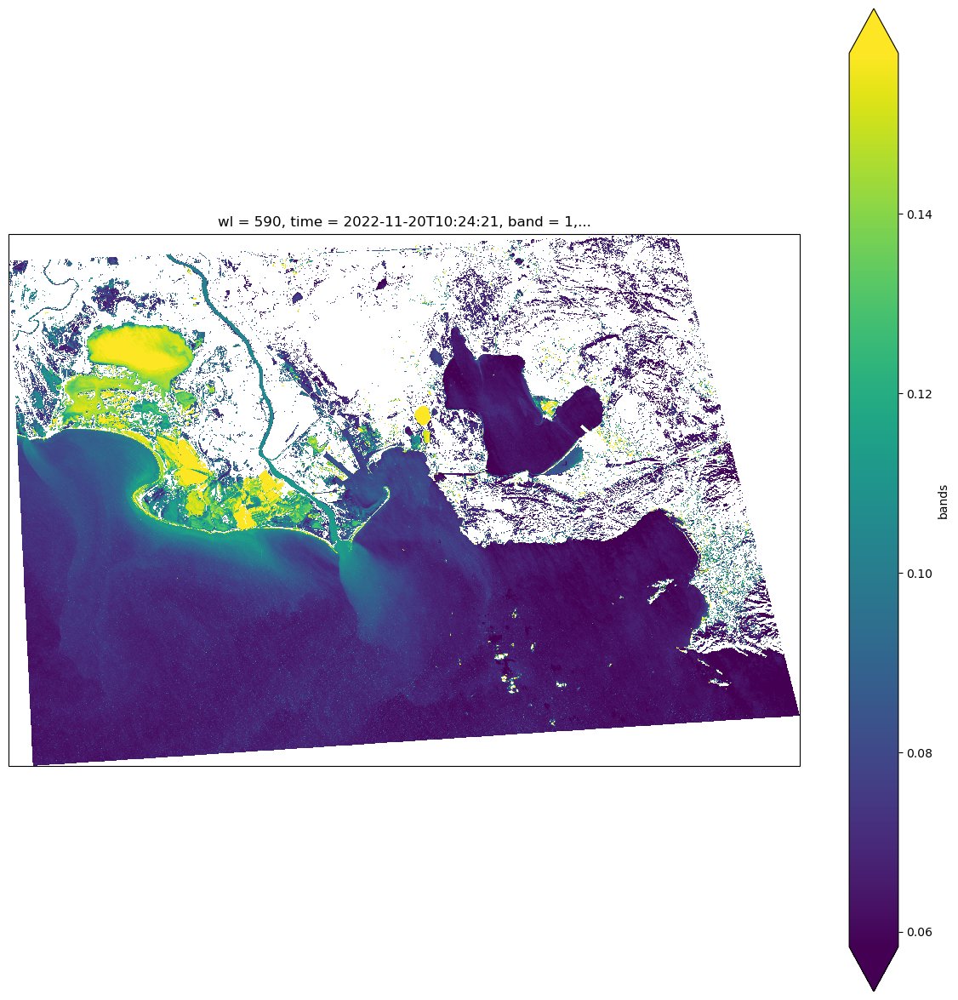

In [32]:
plt.figure(figsize=(15,15))

masked.sel(wl=590).plot.imshow( robust=True,subplot_kws=dict(projection=proj))

If you are happy with your mask you continue and proceed with masking, tweak the threshold values again, otherwise.

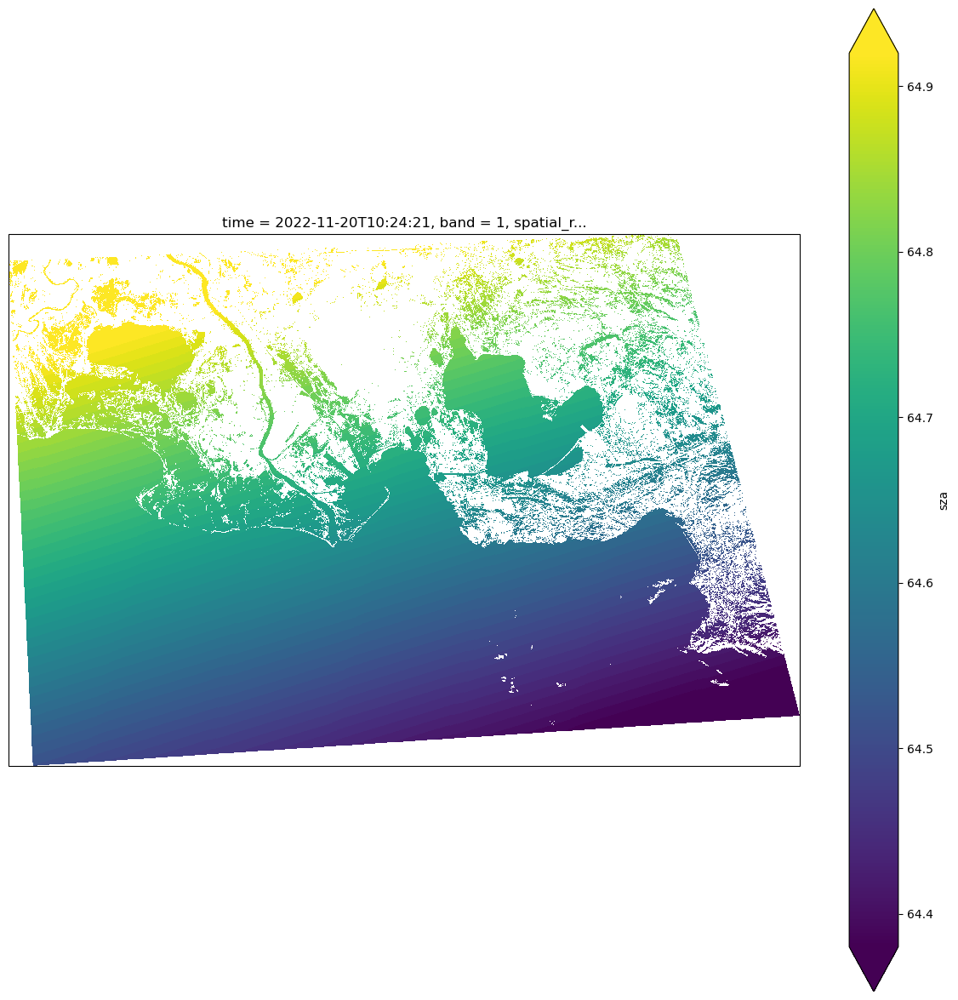

In [33]:
prod.raster['bands'] = masked
prod.raster['sza'] =  prod.raster['sza'].where(mask)


plt.figure(figsize=(15,15))
prod.raster['sza'].plot.imshow( robust=True,subplot_kws=dict(projection=proj))                                             

Preparation of LUT and other input parameters

In [34]:
aero_lut.model

<xarray.DataArray 'model' (model: 5)>
array(['ARCT_rh70', 'COAV_rh70', 'DESE_rh70', 'MACL_rh70', 'URBA_rh70'],
      dtype=object)
Coordinates:
  * model    (model) object 'ARCT_rh70' 'COAV_rh70' ... 'MACL_rh70' 'URBA_rh70'

In [35]:
models = ['ARCT_rh70', 'COAV_rh70', 'DESE_rh70', 'MACL_rh70', 'URBA_rh70']
Nwl,height,width  = prod.raster.bands.shape
chunk = 256
pressure_ref=101500.

cams_aot_ref = cams.cams_aod.interp(wl=550,method='quadratic').compute() #*0.7#.interp(x=prod.raster.x,y=prod.raster.y).compute()#.plot.imshow()
aot_ref_raster = cams_aot_ref
iwl_swir = [-2, -1]
aero_lut_=aero_lut.sel(wind=_wind,method='nearest').sel(model=opac_model)#.isel(model=[4,2]).mean('model') # #opac_model)

In [36]:
aero_lut_

<xarray.Dataset>
Dimensions:            (aot_ref: 10, wl: 10, sza: 45, vza: 14, azi: 73)
Coordinates:
  * wl                 (wl) float32 350.0 400.0 500.0 ... 2.2e+03 2.5e+03
  * aot_ref            (aot_ref) float32 0.0 0.001 0.01 0.1 ... 0.5 0.7 1.0 1.5
  * sza                (sza) float32 0.0 2.0 4.0 6.0 8.0 ... 82.0 84.0 86.0 88.0
    wind               float64 8.0
  * vza                (vza) float32 0.0 1.14 2.62 4.11 ... 16.06 17.55 19.05
  * azi                (azi) float32 0.0 5.0 10.0 15.0 ... 350.0 355.0 360.0
    model              <U9 'COAV_rh70'
Data variables: (12/18)
    wl_ref             (aot_ref, wl) float32 ...
    Cext_ref           (aot_ref, wl) float32 ...
    ssa_ref            (aot_ref, wl) float32 ...
    aot                (aot_ref, wl) float32 ...
    Cext               (aot_ref, wl) float32 ...
    ssa                (aot_ref, wl) float32 ...
    ...                 ...
    Eu                 (aot_ref, wl, sza) float32 ...
    Eo                 (aot_ref, wl, sza) float32 ...
    Eddir              (aot_ref, wl, sza) float32 ...
    Eudir              (aot_ref, wl, sza) float32 ...
    Eodir              (aot_ref, wl, sza) float32 ...
    I                  (aot_ref, wl, sza, vza, azi) float32 ...

In [37]:
ang_resol={'sza':0.1, 'vza':0.1, 'raa_round':0}
szamin,szamax=float(prod.raster['sza'].min()),float(prod.raster['sza'].max())
vzamin,vzamax=float(prod.raster.isel(wl=0)['vza'].min()),float(prod.raster.isel(wl=0)['vza'].max())
# check for out-of-range
def check_out_of_range(vmin,vmax,ceiling=88):
    vmin = np.max([0,vmin])
    vmax = np.min([ceiling,vmax])
    return vmin,vmax
szamin,szamax = check_out_of_range(szamin,szamax)
vzamin,vzamax = check_out_of_range(vzamin,vzamax,ceiling=25)

sza_ = np.arange(szamin,szamax+ang_resol['sza'],ang_resol['sza'])
vza_ = np.arange(vzamin,vzamax+ang_resol['vza'],ang_resol['vza'])

azi_=(180-np.unique(prod.raster.isel(wl=0)['raa'].round(ang_resol['raa_round'])))%360
azi_ = azi_[~np.isnan(azi_)]
#azi_ = np.arange(0,361,1)
print(szamin,szamax)
print(vzamin,vzamax)
print(azi_)

64.33000183105469 65.02999877929688
0.29999998211860657 4.659999847412109
[151. 150. 149. 148. 147. 146. 145. 144. 143. 142. 141. 140. 139. 138.
 132. 131. 130. 126. 124. 116. 115. 114. 108. 107. 106. 105. 104. 103.
 102. 101. 100.  99.  98.  97.  96.  95.  94.  93.  92.  91.  90.  89.
  88.  87.  86.  85.  84.  83.  82.  81.  80.  79.  78.  77.  76.  75.
  74.  73.  72.  71.  70.  69.  68.  67.  66.  65.  64.  63.  62.  61.
  60.  59.  58.  57.  56.  55.  54.  53.  52.  51.  50. 313. 312. 311.
 310. 309. 308. 307. 306. 305. 304. 303. 302. 296. 294. 290. 289. 288.
 287. 286. 285. 284. 283. 282. 265. 264. 263. 262. 261. 260. 259. 258.
 257. 256. 255. 254. 253. 252. 251. 250. 249. 248. 247. 246. 245. 244.
 243. 242. 241. 240. 239. 238. 237. 236. 235. 234. 233. 232. 231. 230.
 229. 228. 227. 226. 225. 224. 223. 222. 221. 220. 219. 218. 217. 216.
 215. 214. 213. 212. 211. 210. 209. 208.]


In [38]:
sza_lut_step=2
vza_lut_step=2
sza_slice=slice(np.min(sza_)-sza_lut_step,np.max(sza_)+sza_lut_step)
vza_slice=slice(np.min(vza_)-vza_lut_step,np.max(vza_)+vza_lut_step)
tweak=3
aot_ref_ =np.unique((aot_ref_raster/tweak).round(3))*tweak
aot_ref_min = aot_ref_raster.min()
aot_ref_max = aot_ref_raster.max()
aot_lut = aero_lut_.aot.interp(wl=wl_true,method='quadratic')
aot_lut = aot_lut.interp(aot_ref=np.linspace(aot_ref_min,aot_ref_max,1000))#.plot(hue='wl')

In [39]:
Rdiff_lut = aero_lut_.I.sel(sza=sza_slice,vza=vza_slice).interp(wl=wl_true,method='quadratic').interp(azi=azi_)

In [40]:
Rdiff_lut =  Rdiff_lut.interp(sza=sza_,vza=vza_)
Rray =  Rdiff_lut.sel(aot_ref=0)
Rdiff_lut = Rdiff_lut.interp(aot_ref=aot_ref_,method='quadratic')

szas = Rdiff_lut.sza.values
vzas = Rdiff_lut.vza.values
azis = Rdiff_lut.azi.values
aot_refs = Rdiff_lut.aot_ref.values

In [41]:
Ttot_Ed_ = Ttot_Ed.sel(model=opac_model).sel(wind=_wind, method='nearest').interp(sza=szas).interp(
    aot_ref=aot_ref_, method='quadratic').interp(wl=wl_true, method='cubic').Ttot_Ed
Ttot_Lu_ = Ttot_Ed.sel(model=opac_model).sel(wind=_wind, method='nearest').interp(sza=vzas).interp(
    aot_ref=aot_ref_, method='quadratic').interp(wl=wl_true, method='cubic').Ttot_Ed ** 1.05

_sunglint_eps=sunglint_eps.values
# prepare aerosol parameters
aot_ref_raster = cams_aot_ref.interp(x= prod.raster.x, y= prod.raster.y).drop('wl')
aot_ref_raster.name='aot550'
#_aot = aot_lut.interp(aot_ref=_aot_ref)
_pressure = cams.raster.sp.interp(x= prod.raster.x, y= prod.raster.y).values
#_pressure = palt.values
_rot = rot.values

### And finally run the GRS kernel !!!

In [42]:
Rrs_tmp = np.full((Nwl, height, width), np.nan, dtype=prod._type)
Rf_tmp = np.full((height,width), np.nan, dtype=prod._type)
for iy in range(0, height, chunk):
    yc = min(height, iy + chunk)
    
    for ix in range(0, width, chunk):
        xc = min(width, ix + chunk)
       
        _band_rad = prod.raster.bands[:, iy:yc, ix:xc]
        
        Nwl, Ny, Nx = _band_rad.shape
        #if Ny == 0 or Nx == 0:
        #    continue
        arr_tmp = np.full((Nwl, Ny, Nx), np.nan, dtype=np.float32)
        
        # subsetting
        _sza = prod.raster.sza[iy:yc, ix:xc]  # .values
        if monoview:
            _raa = prod.raster.raa[iy:yc, ix:xc]           
            _vza = prod.raster.vza[iy:yc, ix:xc]
            _vza_mean = _vza.values
        else:
            _raa = prod.raster.raa[:, iy:yc, ix:xc]           
            _vza = prod.raster.vza[:, iy:yc, ix:xc]
            _vza_mean = np.mean(_vza, axis=0).values
        
        _azi = (180. - _raa) % 360
        _air_mass_ = acutils.Misc.air_mass(_sza, _vza).values  # air_mass[:, iy:yc,ix:xc] #air_mass(_sza,_vza).values #_p_slope = prod.raster.p_slope[:, iy:yc,ix:xc]
        _p_slope_ = prod.p_slope(_sza, _vza, _raa, sigma2=_sigma2, monoview=monoview).values  # _p_slope[:, iy:yc,ix:xc]
        _aot_ref = aot_ref_raster.values[iy:yc, ix:xc]
        _pressure_ = _pressure[iy:yc, ix:xc] / pressure_ref           
        
        # get LUT values
        _Rdiff = _R_.interp_Rlut(szas, _sza.values,
                                  vzas, _vza.values,
                                  azis, _azi.values,
                                  aot_refs, _aot_ref,
                                  Nwl, Ny, Nx, Rdiff_lut.values)
        _Rray = _R_.interp_Rlut_rayleigh(szas, _sza.values,
                                  vzas, _vza.values,
                                  azis, _azi.values,
                                  Nwl, Ny, Nx, Rray.values)
        #_Rdiff = _Rdiff + (_pressure_ - 1) *  _Rray 
       
        _aot = _R_._interp_aotlut(aot_lut.aot_ref.values, _aot_ref, Nwl, Ny, Nx, aot_lut.values)
        
        #  correction for diffuse light
        Rcorr = _band_rad.values - _Rdiff
        
         # construct wl,y,x raster for Rayleigh optical thickness
        _rot_raster = _R_._multiplicate(_rot, _pressure_, arr_tmp)
       
        # direct transmittance up/down
        Tdir = acutils.Misc.transmittance_dir(_aot, _air_mass_, _rot_raster)

        # vTotal transmittance (for Ed and Lu)
        Tdown = _R_._interp_Tlut(szas, _sza.values, Ttot_Ed_.aot_ref.values, _aot_ref, Nwl, Ny, Nx,
                                         Ttot_Ed_.values)
        Tup = _R_._interp_Tlut(vzas, _vza_mean, Ttot_Ed_.aot_ref.values, _aot_ref, Nwl, Ny, Nx, Ttot_Lu_.values)
        Ttot_du = Tdown * Tup
        
        Rf = np.full((len(iwl_swir), Ny, Nx), np.nan, dtype=np.float32)
        
        for iwl in iwl_swir:
            if monoview:
                Rf[iwl] = Rcorr[iwl] / (Tdir[iwl] * _sunglint_eps[iwl] * _p_slope_)
            else:
                Rf[iwl] = Rcorr[iwl] / (Tdir[iwl] * _sunglint_eps[iwl] * _p_slope_[iwl])
        Rf[Rf<0]=0.
        Rf = np.min(Rf, axis=0)
        Rf_tmp[iy:yc, ix:xc] = Rf
        
        Rf = _R_._multiplicate(_sunglint_eps, Rf, arr_tmp)
        Rf = Tdir * _p_slope_ * Rf
        
        Rrs_tmp[:, iy:yc, ix:xc] = ((Rcorr - Rf) / np.pi)/ Ttot_du
        
print('success')

success


In [43]:
xres = xr.Dataset(dict(Rrs=(['wl',"y", "x"],Rrs_tmp),
                       BRDFg= (["y", "x"],Rf_tmp)),
                  coords=dict(wl=prod.raster.wl,
                              x=prod.raster.x,
                              y=prod.raster.y),
                              )
l2_prod = xr.merge([aot_ref_raster, xres])
#l2a = L2aProduct(prod, l2_prod, cams, gas_trans)
l2_prod

<xarray.Dataset>
Dimensions:      (x: 3078, y: 2070, wl: 8)
Coordinates:
    time         datetime64[ns] 2022-11-20T10:24:21
    band         int64 1
    spatial_ref  int64 0
  * x            (x) float64 6.109e+05 6.11e+05 6.11e+05 ... 7.032e+05 7.032e+05
  * y            (y) float64 4.836e+06 4.836e+06 ... 4.774e+06 4.773e+06
  * wl           (wl) int64 443 490 560 590 665 865 1610 2190
Data variables:
    aot550       (y, x) float64 0.02464 0.02464 0.02465 ... 0.03608 0.03608
    Rrs          (wl, y, x) float32 nan nan nan nan nan ... nan nan nan nan nan
    BRDFg        (y, x) float32 nan nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:  CF-1.6
    history:      2024-02-21 18:34:02 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

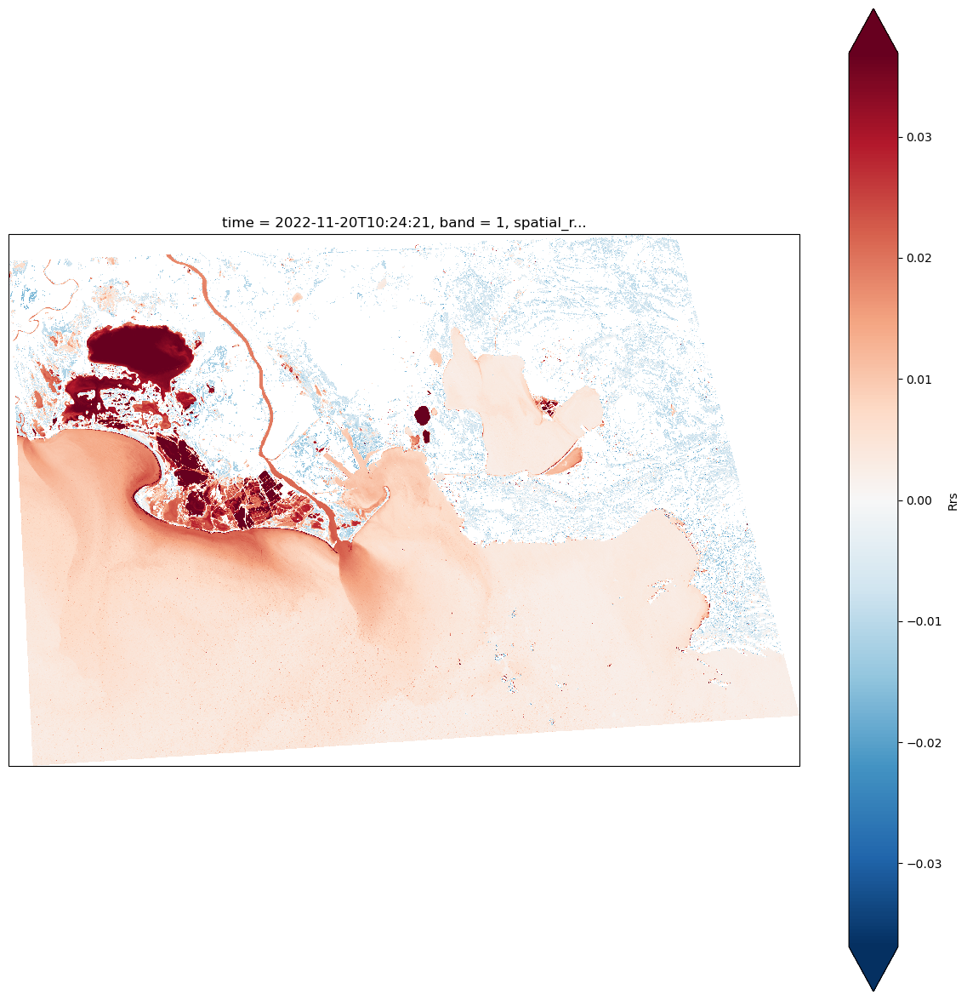

In [44]:
plt.figure(figsize=(15,15))

l2_prod.Rrs.sel(wl=590).plot.imshow( robust=True,subplot_kws=dict(projection=proj))

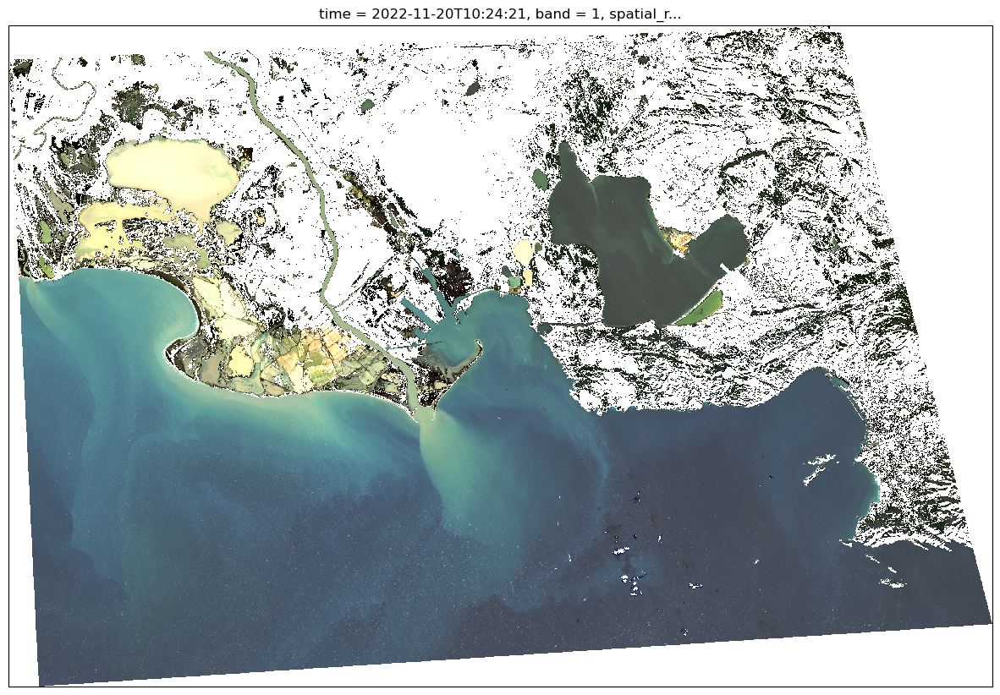

In [45]:
plt.figure(figsize=(15,15))

l2_prod.Rrs.sel(wl=[665,560,490]).plot.imshow(rgb='wl', robust=True,subplot_kws=dict(projection=proj))

# L2A to L2B

### Mask bad quality pixels

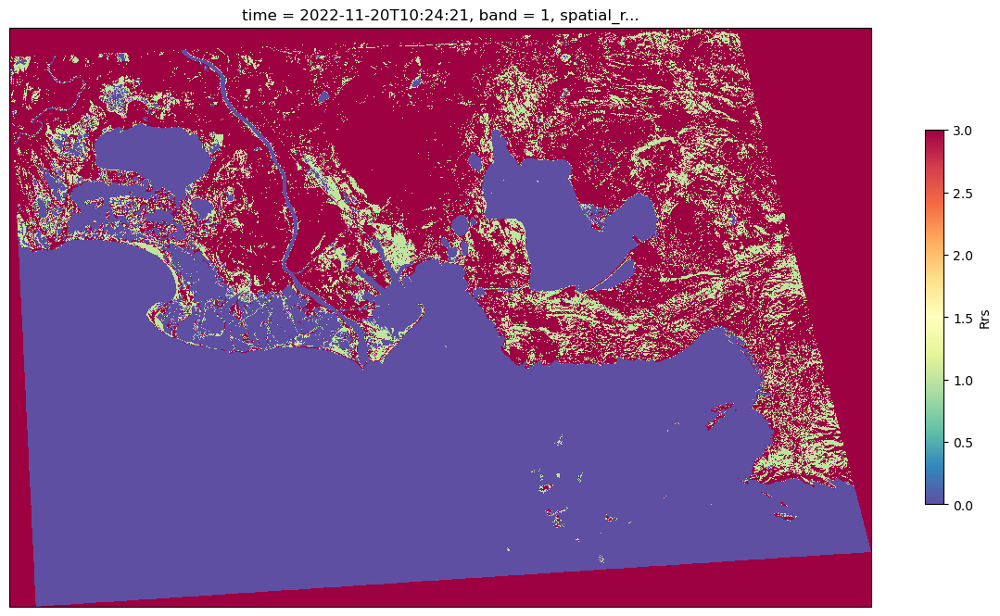

In [46]:
Rrs_blue_avg=0.05
Rrs = l2_prod.Rrs
mask=xr.where((Rrs.sel(wl=490,method='nearest')<0)|(Rrs.sel(wl=565,method='nearest')<0),1,0)
mask=mask.where((Rrs.sel(wl=443,method='nearest')<2*Rrs_blue_avg),2)
mask=mask.where((Rrs.sel(wl=443,method='nearest')<3*Rrs_blue_avg),3)
#mask=mask.where((l2a.l2_prod.wv_band)<0.1,4)


plt.figure(figsize=(15,15))

mask.plot.imshow(cmap=plt.cm.Spectral_r,robust=True,subplot_kws=dict(projection=proj),cbar_kwargs={'shrink':0.35})


Apply mask

In [47]:
Rrs=Rrs.where(mask==0)

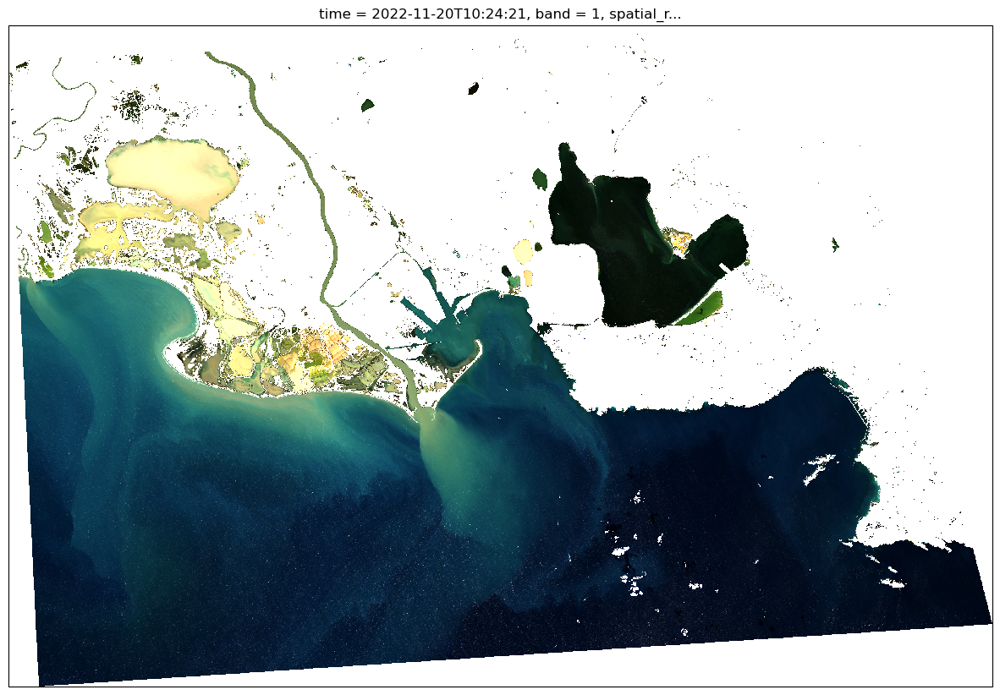

In [48]:
plt.figure(figsize=(15,15))
#(dem.shaded+1).plot.imshow(robust=True,subplot_kws=dict(projection=proj),cmap=plt.cm.Greys_r,cbar_kwargs={'shrink':0.4})
Rrs.sel(wl=[665,560,490]).plot.imshow(rgb='wl', robust=True,subplot_kws=dict(projection=proj))

## Check Rrs spectra 

In [49]:
v=visual.view_spectral(l2_prod.Rrs,reproject=True)

In [50]:
v.minmax=[0,0.1]
v.visu()

Column
    [0] WidgetBox
        [0] Markdown(str)
        [1] Column
            [0] Row
                [0] Markdown(str)
                [1] RadioButtonGroup(options=[0, 1, 2, 3, 4, 5, 6, 7], value=2)
            [1] Row
                [0] Row
                    [0] Markdown(str)
                    [1] DatePicker(enabled_dates=[datetime.date(2022, ...], start=datetime.date(2022, ..., value=datetime.date(2022, ...)
                [1] Row
                    [0] Markdown(str)
                    [1] Select(options=['CartoDark', ...], value='CartoDark')
            [2] Row
                [0] Row
                    [0] Markdown(str)
                    [1] EditableRangeSlider(end=0.1, name='Range Slider', step=0.0001, value=(0, 0.02), width=300)
                [1] Row
                    [0] Markdown(str)
                    [1] FloatSlider(name='Opacity', step=0.05, value=0.95)
                [2] Row
                    [0] Markdown(str)
                    [1] Select(options=['CET_D13', 'bky', ...], value='CET_D13')
        [2] HoloViews(DynamicMap, height=800, sizing_mode='fixed', width=1200)

In [52]:
geom_ = v.get_geom(v.aoi_stream,crs=prod.raster.rio.crs)

raster_clipped = xr.Dataset()
l2_prod.rio.clip(geom_.geometry.values)
for param in l2_prod.keys():
    da = l2_prod[param]
    if 'x' in da.dims and 'y' in da.dims:
        raster_clipped[param]=da.rio.clip(geom_.geometry.values)
    else:
        raster_clipped[param]=da
raster_clipped.attrs = prod.raster.attrs


In [53]:
stacked = raster_clipped.Rrs.sel(wl=slice(400,1000)).stack(gridcell=["y", "x"]).dropna('gridcell',thresh=0)


In [54]:
group_coord ='wl'
stat_coord='gridcell'
stats = xr.Dataset({'median':stacked.groupby(group_coord).median(stat_coord)})
stats['q25'] = stacked.groupby(group_coord).quantile(0.25,dim=stat_coord)
stats['q75'] = stacked.groupby(group_coord).quantile(0.75,dim=stat_coord)
stats['min'] = stacked.groupby(group_coord).min(stat_coord)
stats['max'] = stacked.groupby(group_coord).max(stat_coord)
stats['mean'] = stacked.groupby(group_coord).mean(stat_coord)
stats['std'] = stacked.groupby(group_coord).std(stat_coord)
stats['pix_num'] = stacked.count(stat_coord)

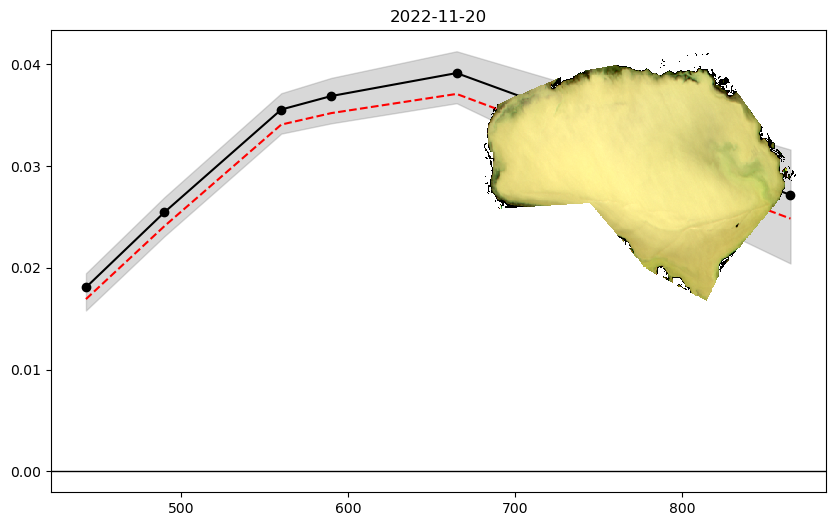

In [55]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

bands=[3,2,1]
fig, axs = plt.subplots(1,1, figsize=(10, 6))#,sharey=True



date = stats.time.dt.date.values
axins = inset_axes(axs, width="45%", height="60%",
               bbox_to_anchor=(.55, .4, 0.9, 0.9),
               bbox_transform=axs.transAxes, loc=3)


raster_clipped.Rrs.isel(wl=bands).plot.imshow(robust=True,ax=axins)
axins.set_title('')
axins.set_axis_off()
axs.axhline(y=0,color='k',lw=1)
axs.plot(stats.wl,stats['median'],marker='o',c='k')
axs.plot(stats.wl,stats['mean'],c='red',ls='--')
axs.fill_between(stats.wl, stats['q25'], stats['q75'],alpha=0.3,color='grey')
axs.set_title(date)
plt.show()

## Check water quality parameters (e.g., Chl-a concentration from diverse "algorithms")¶


### Total suspended particulate matter (SPM) from Nechad et al., 2010, 2016 formulation
### spm in mg/L

In [56]:
a = [610.94*np.pi, 0.2324/np.pi]
Rrs_ = Rrs.isel(wl=3)
spm = a[0] * Rrs_ / (1 - ( Rrs_/ a[1]))
spm.name='SPM_N2016'
spm.attrs['units']='mg/L'
spm.attrs['description']='Concentration of suspended particulate matter from band 665 nm'

a = [428.277*np.pi, 0.3051/np.pi]
Rrs_ = Rrs.isel(wl=3)
spm2 = a[0] * Rrs_ / (1 - ( Rrs_/ a[1]))
spm2.name='SPM_N2016_han1'
spm2.attrs['units']='mg/L'
spm2.attrs['description']='Concentration of suspended particulate matter from band 665 nm'


a = [1444.853*np.pi, 0.3539/np.pi]
Rrs_ = Rrs.isel(wl=3)
spm3 = a[0] * Rrs_ / (1 - ( Rrs_/ a[1]))
spm3.name='SPM_N2016_han2'
spm3.attrs['units']='mg/L'
spm3.attrs['description']='Concentration of suspended particulate matter from band 665 nm'


Text(0.5, 1.0, 'Nechad_HAN SAA-H')

<Figure size 2500x1800 with 0 Axes>

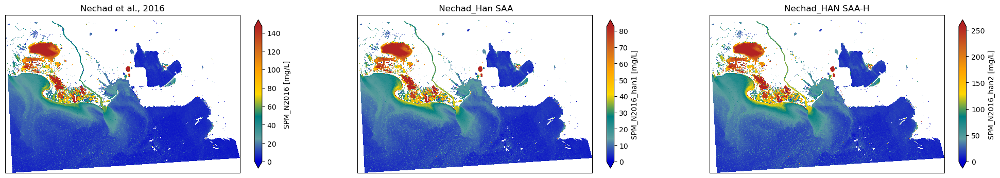

In [57]:
plt.figure(figsize=(25,18))
colors = ['mediumblue','cadetblue','teal','gold','orange','chocolate','firebrick']
cmap = mpl.colors.LinearSegmentedColormap.from_list('spm',colors)
fig = plt.figure(figsize=(25, 15))
ax = plt.subplot(1, 3, 1, projection=proj)
spm.plot.imshow(cmap=cmap,ax=ax,robust=True,cbar_kwargs={'shrink':0.25},vmin=0)
ax.set_title('Nechad et al., 2016')
ax = plt.subplot(1, 3,2, projection=proj)
spm2.plot.imshow(cmap=cmap,ax=ax,robust=True,cbar_kwargs={'shrink':0.25},vmin=0)
ax.set_title(' Nechad_Han SAA')
ax = plt.subplot(1, 3,3, projection=proj)
spm3.plot.imshow(cmap=cmap,ax=ax,robust=True,cbar_kwargs={'shrink':0.25},vmin=0)
ax.set_title('Nechad_HAN SAA-H')

### Check blue over green ratio for Chl retrieval with OC2 from NASA
$log_{10}(chlor\_a) = a_0 + \sum\limits_{i=1}^4 a_i \left(log_{10}\left(\frac{R_{rs}(\lambda_{blue})}{R_{rs}(\lambda_{green})}\right)\right)^i$

In [58]:

# NASA OC2 fro MODIS; bands 488, 547 nm
a_modis = [0.2500,-2.4752,1.4061,-2.8233,0.5405]
# NASA OC2 for OCTS; bands 490, 565 nm
a_octs = [0.2236,-1.8296,1.9094,-2.9481,-0.1718]
# Pelevin et al, 2023, Issyk-Kul
a = [0.1977,-1.8117,1.9742,-2.5635,-0.7218]
# mona et al.
a_mona = [0.484,-2.109,2.880,-0.690,-1.040]

ratio = np.log10(Rrs.isel(wl=1)/Rrs.isel(wl=2))
chl={}
for name,a in [('nasa',a_octs),('mona',a_mona)]:
    logchl=0
    for i in range(len(a)):
        logchl+=a[i]*ratio**i
    _chl = 10**(logchl)
    _chl.name='Chla_'+name
    _chl.attrs['units']='mg.m-3'
    _chl.attrs['description']= 'Chl-a concentration from NASA OC2 with OCTS parameterization, bands 490, 565 nm',
    _chl = _chl.where((_chl >= 0) & (_chl <= 2000))
    chl[name]=_chl

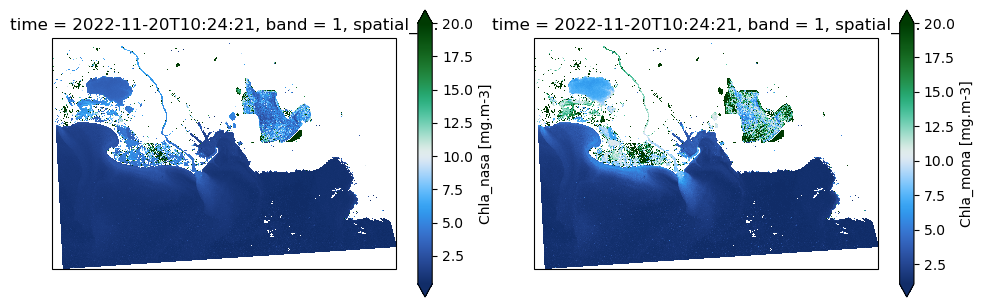

In [59]:

import colorcet as cc
ncols=2
nrows=1
vmax=20
fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*5.1,5*nrows+5),sharey=True,sharex=True,subplot_kw={'projection': proj})   
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.15, wspace=0.12,)
for ii, (name,_chl) in enumerate(chl.items()):
    _chl.plot.imshow(cmap=cc.cm.CET_D13,robust=True,ax=axs[ii],cbar_kwargs={'shrink':0.35},vmax=vmax)

### CDOM retrieval based on Brezonik et al, 2015

In [60]:
a = [1.872,-0.83]
acdom = np.exp(a[0] + a[1] * np.log(Rrs.isel(wl=1)/Rrs.isel(wl=5)))
acdom.name='a_cdom_b2015'
acdom.attrs['units']='m-1'
acdom.attrs['description']='CDOM absorption at 440 nm-1'
acdom= acdom.where((acdom >= 0) & (acdom <= 60))


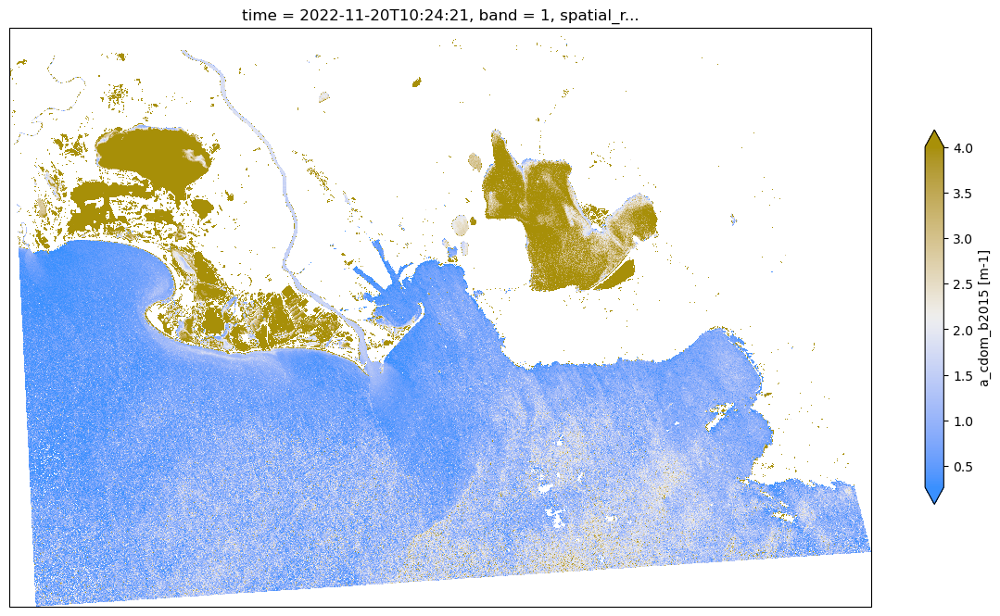

In [61]:
plt.figure(figsize=(15,15))

acdom.plot.imshow(cmap=cc.cm.CET_CBD1,robust=True,subplot_kws=dict(projection=proj),cbar_kwargs={'shrink':0.35},vmax=4)

In [62]:
def cPOC_2(Rrs,p=[2.873,0.945,0.025]):
    ratio1=Rrs.sel(wl=665,method='nearest') / Rrs.sel(wl=490,method='nearest') 
    ratio2=Rrs.sel(wl=665,method='nearest') / Rrs.sel(wl=565,method='nearest') 
    ratio = np.log10(xr.concat([ratio1.assign_coords({'num':1}),ratio1.assign_coords({'num':2})],dim='num').max('num'))
    
    Xpoc = p[0]+p[1]*ratio+p[2]*ratio**2
    return 10**Xpoc

poc = cPOC_2(Rrs)
poc.name = 'cPOC_2'

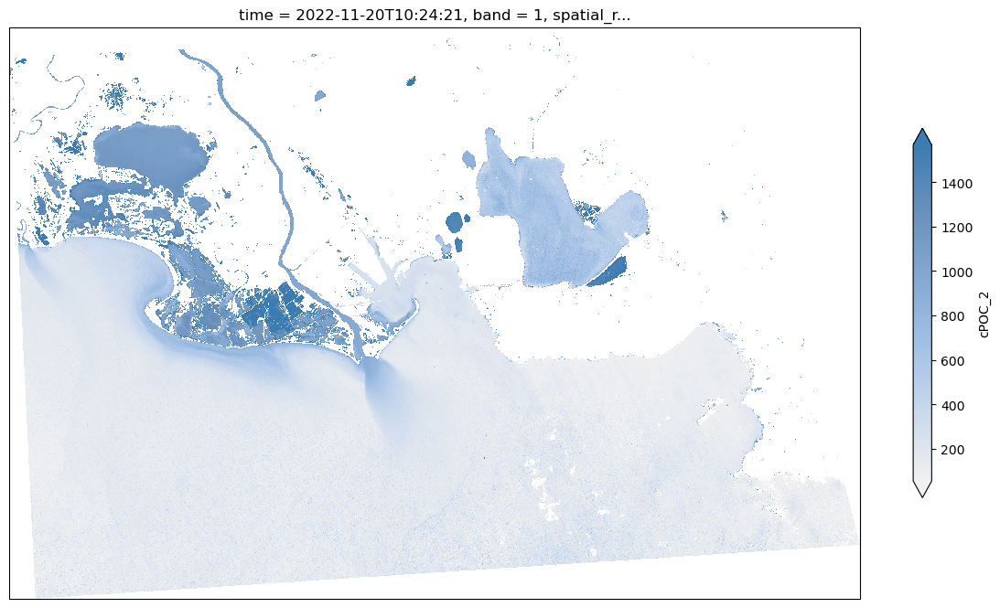

In [63]:
plt.figure(figsize=(15,15))

poc.plot.imshow(cmap=cc.cm.blues,robust=True,subplot_kws=dict(projection=proj),cbar_kwargs={'shrink':0.35})

### Check Optical Water Types (OWT)

owt_file = '/DATA/projet/vrac/owt/Spyrakos_et_al_2018_OWT_inland_mean_standardised.csv'
owt =pd.read_csv(owt_file,index_col=0).stack().to_xarray()
owt = owt.rename({'level_1':'wl'})
owt['wl']=owt.wl.astype(float)


import matplotlib.patches as mpatches

owt_info={
        1:dict(color='olivedrab',label='OWT1: Hypereutrophic waters'),
        2:dict(color='black',label='OWT2: Common case waters'),
        3:dict(color='cadetblue',label='OWT3: Clear waters'),
        4:dict(color='tan',label='OWT4: Turbid waters with organic content'),
        5:dict(color='chocolate',label='OWT5: Sediment-laden waters'),
        6:dict(color='teal',label='OWT6: Balanced optical effects at shorter wavelengths'),
        7:dict(color='blueviolet',label='OWT7: Highly productive cyanobacteria-dominated waters'),
        8:dict(color='plum',label='OWT8: Productive with cyanobacteria waters'),
        9:dict(color='red',label='OWT9: OWT2 with higher $R_{rs}$ at shorter wavelengths'),#'slategrey'
        10:dict(color='orange',label='OWT10: CDOM-rich waters'),
        11:dict(color='gold',label='OWT11: CDOM-rich with cyanobacteria waters'),
        12:dict(color='firebrick',label='OWT12: Turbid waters with cyanobacteria'),
        13:dict(color='mediumblue',label='OWT13: Very clear blue waters'),
        }
colors = ['olivedrab','black','cadetblue','tan','chocolate','teal','blueviolet','plum','red','orange','gold','firebrick','mediumblue']
cmap_owt = mpl.colors.ListedColormap(colors)

patch = []
for key,info in owt_info.items():
    patch.append(mpatches.Patch(color=info['color'], label=info['label']))

fig, ax = plt.subplots(nrows=1,ncols=1, sharex=True,figsize=(9, 6))
ax.minorticks_on()
for iowt,group in owt.groupby('owt'):
    
    group.plot(color=owt_info[iowt]['color'],lw=3)
ax.set_title('' )
ax.set_ylabel('$Standardized\ R_{rs}\ (nm^{-1})$',fontsize=20)
ax.set_xlabel('$Wavelength\ (nm)$',fontsize=20)    
plt.legend(handles=patch,fontsize=13,bbox_to_anchor=(1, .5, 0.5, 0.5))

def SAM(R1,R2):
    denum=(R1*R2).sum('wl')
    denom = (R1**2).sum('wl')**0.5 * (R2**2).sum('wl')**0.5
    return np.arccos(denum/denom)

def SCS(R1,R2):
    R1_avg = R1.mean('wl')
    R2_avg = R2.mean('wl')
    R1_std = R1.std('wl')
    R2_std = R2.std('wl')
    Nwl = len(R1.wl)
    return 1/(Nwl) * ((R1-R1_avg) * (R2-R2_avg)).sum('wl') / (R1_std*R2_std)


Rrs_sat = Rrs.sel(wl=slice(350,800))#.dropna('wl')

Rrs_owt = owt.interp(wl=Rrs_sat.wl)

owt_sam = SAM(Rrs_sat,Rrs_owt)
owt_scs =SCS(Rrs_sat,Rrs_owt)

owt_delta = owt_scs + (1-2*owt_sam/np.pi)/2

fig = plt.figure(figsize=(25, 15))
ax = plt.subplot(1, 2, 1, projection=proj)

cmap = plt.get_cmap('tab20c',13)
(owt_delta.fillna(-1).argmax('owt')+1).where(Rrs_sat.isel(wl=1)>0).plot.imshow(vmin=0.5,vmax=13.5,cmap=cmap_owt,cbar_kwargs={ 'ticks':range(1,14),'shrink': 0.4},ax=ax)
ax = plt.subplot(1, 2, 2, projection=proj)
cmap = plt.get_cmap('RdBu')#,13)
(owt_delta.max('owt')).where(Rrs_sat.isel(wl=1)>0).plot.imshow(robust=True,cmap=cmap,ax=ax, cbar_kwargs={ 'shrink': 0.4})

In [ ]:
#l2b.to_netcdf('/DATA/vrac/test_l2b.nc')